In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/LICENSE
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/README.md
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50-human.xlsx
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-257349-A-15.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/2-122820-B-36.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-115920-A-22.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-172649-C-40.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/

In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

def plot_genre_spectrogram(audio_path, genre_title):
    y, sr = librosa.load(audio_path, duration=10) # Load first 10s
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Mel-Spectrogram: {genre_title}')
    plt.tight_layout()
    plt.show()

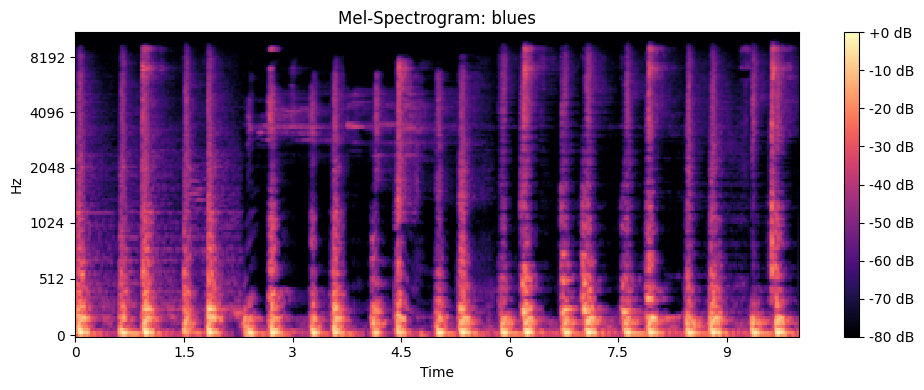

In [3]:
plot_genre_spectrogram('/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems/blues/blues.00001/drums.wav', 'blues')

In [4]:
import os, random, warnings
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
from joblib import Parallel, delayed
warnings.filterwarnings('ignore')

# ── Key speed knobs ────────────────────────────────────────────────
SR          = 16000   
DURATION    = 10      # seconds — 3× faster than 30s
N_MELS      = 128
HOP_LENGTH  = 256     # keeps time resolution reasonable at 16kHz/10s
N_FFT       = 1024
SAMPLES_PER_GENRE = 600   
EPOCHS      = 20
BATCH_SIZE  = 64
N_TTA       = 3       # test-time augmentation copies
N_JOBS      = 4       # parallel workers for feature extraction
# ──────────────────────────────────────────────────────────────────

BASE_DIR   = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_DIR  = os.path.join(BASE_DIR, 'genres_stems')
NOISE_DIR  = os.path.join(BASE_DIR, 'ESC-50-master/audio')

GENRES = ['blues','classical','country','disco','hiphop',
          'jazz','metal','pop','reggae','rock']
GENRE2IDX = {g: i for i, g in enumerate(GENRES)}

# Pre-load noise file list once
NOISE_FILES = [f for f in os.listdir(NOISE_DIR)
               if f.endswith('.wav') or f.endswith('.ogg')]
print(f'Noise files: {len(NOISE_FILES)}')
print('Setup complete.')

Noise files: 2000
Setup complete.


In [5]:
def make_one_sample(genre_path, sr=SR, duration=DURATION):
    """
    Returns mel-spectrogram (np.float32, shape [N_MELS, T]) for one synthetic mashup.
    Everything in one function — no intermediate saves.
    """
    song_folders = [f for f in os.listdir(genre_path)
                    if os.path.isdir(os.path.join(genre_path, f))]
    selected = random.sample(song_folders, min(4, len(song_folders)))
    if len(selected) < 4:
        selected = (selected * 4)[:4]

    stem_names = ['drums.wav', 'vocals.wav', 'bass.wav', 'others.wav']
    mixed = np.zeros(sr * duration, dtype=np.float32)

    for i, stem in enumerate(stem_names):
        path = os.path.join(genre_path, selected[i], stem)
        if not os.path.exists(path):
            path = path.replace('others.wav', 'other.wav')
        if not os.path.exists(path):
            continue

        offset = random.uniform(0, 15)   # random start in the song
        try:
            y, _ = librosa.load(path, sr=sr, offset=offset, duration=duration)
        except Exception:
            continue

        # Tempo stretch — mirrors how test mashups are built
        if random.random() < 0.5:
            y = librosa.effects.time_stretch(y, rate=random.uniform(0.88, 1.12))

        y = librosa.util.fix_length(y, size=sr * duration)

        if random.random() > 0.1:   # 10% stem dropout
            mixed += y * random.uniform(0.3, 1.2)

    # Add 1–2 noise clips at random positions
    for _ in range(random.randint(1, 2)):
        npath = os.path.join(NOISE_DIR, random.choice(NOISE_FILES))
        try:
            ny, _ = librosa.load(npath, sr=sr)
        except Exception:
            continue
        tlen = sr * duration
        if len(ny) < tlen:
            start = random.randint(0, tlen - len(ny))
            pad = np.zeros(tlen, dtype=np.float32)
            pad[start:start + len(ny)] = ny
            ny = pad
        else:
            ny = ny[:tlen]
        mixed += ny * random.uniform(0.03, 0.22)

    # Normalize
    mx = np.max(np.abs(mixed))
    if mx > 0:
        mixed /= mx

    # Mel spectrogram — fixed size output
    mel = librosa.feature.melspectrogram(
        y=mixed, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    # Normalize per-sample
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-8)
    return mel_db


def generate_genre_samples(genre, n=SAMPLES_PER_GENRE):
    """Parallel worker: generate n samples for one genre."""
    genre_path = os.path.join(STEMS_DIR, genre)
    mels, labels = [], []
    for _ in range(n):
        try:
            mel = make_one_sample(genre_path)
            mels.append(mel)
            labels.append(GENRE2IDX[genre])
        except Exception as e:
            pass  # skip failures silently
    return mels, labels

print('Functions defined.')

Functions defined.


In [6]:
all_mels, all_labels = [], []

for genre in GENRES:
    print(f'Generating {SAMPLES_PER_GENRE} samples for: {genre}')
    genre_path = os.path.join(STEMS_DIR, genre)
    mels, labels = [], []
    for _ in tqdm(range(SAMPLES_PER_GENRE)):
        try:
            mel = make_one_sample(genre_path)
            mels.append(mel)
            labels.append(GENRE2IDX[genre])
        except Exception:
            pass
    all_mels.extend(mels)
    all_labels.extend(labels)

X = np.array(all_mels, dtype=np.float32)   # (N, 128, T)
y = np.array(all_labels, dtype=np.int64)
print(f'Dataset shape: {X.shape}, Labels: {y.shape}')

Generating 600 samples for: blues


100%|██████████| 600/600 [03:28<00:00,  2.87it/s]


Generating 600 samples for: classical


100%|██████████| 600/600 [03:12<00:00,  3.12it/s]


Generating 600 samples for: country


...

Generating 600 samples for: reggae


100%|██████████| 600/600 [03:34<00:00,  2.80it/s]


Generating 600 samples for: rock


100%|██████████| 600/600 [03:40<00:00,  2.72it/s]


Dataset shape: (6000, 128, 626), Labels: (6000,)


In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score


class MelDataset(Dataset):
    def __init__(self, mels, labels, augment=False):
        # mels: (N, n_mels, T)  ->  add channel dim inside __getitem__
        self.mels    = torch.tensor(mels,   dtype=torch.float32)
        self.labels  = torch.tensor(labels, dtype=torch.long)
        self.augment = augment

    def __len__(self): return len(self.mels)

    def _spec_augment(self, mel):
        mel = mel.clone()
        _, n_mels, T = mel.shape
        for _ in range(2):                        # freq masking
            f  = random.randint(0, 15)
            f0 = random.randint(0, n_mels - f)
            mel[:, f0:f0+f, :] = 0
        for _ in range(2):                        # time masking
            t  = random.randint(0, 30)
            t0 = random.randint(0, max(1, T - t))
            mel[:, :, t0:t0+t] = 0
        return mel

    def __getitem__(self, idx):
        mel = self.mels[idx].unsqueeze(0)   # (1, n_mels, T)
        if self.augment:
            mel = self._spec_augment(mel)
        return mel, self.labels[idx]


class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch),
        )
        self.relu = nn.ReLU()
    def forward(self, x): return self.relu(x + self.net(x))


class MelCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        def block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch), nn.ReLU(),
                nn.MaxPool2d(2, 2),
                ResBlock(out_ch),
            )
        self.encoder = nn.Sequential(
            block(1,   32),
            block(32,  64),
            block(64,  128),
            block(128, 256),
        )
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.head(self.gap(self.encoder(x)))


print('Model classes defined.')

Model classes defined.


In [8]:
# ── Train / Val split ──────────────────────────────────────────────
X_tr, X_vl, y_tr, y_vl = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

train_loader = DataLoader(
    MelDataset(X_tr, y_tr, augment=True),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    MelDataset(X_vl, y_vl, augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

model = MelCNN().to(device)
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')

criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer  = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_f1, best_epoch = 0.0, 0

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    scheduler.step()

    # Validate
    model.eval()
    preds_all, true_all = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            preds_all.extend(model(xb.to(device)).argmax(1).cpu().numpy())
            true_all.extend(yb.numpy())

    vf1 = f1_score(true_all, preds_all, average='macro')
    vacc = np.mean(np.array(preds_all) == np.array(true_all))

    if vf1 > best_f1:
        best_f1, best_epoch = vf1, epoch
        torch.save(model.state_dict(), 'best_cnn.pth')

    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f'Ep {epoch:3d} | loss {train_loss/len(train_loader):.3f} | '
              f'val_acc {vacc:.3f} | val_f1 {vf1:.3f} | best_f1 {best_f1:.3f}')

print(f'\nBest val F1: {best_f1:.4f} at epoch {best_epoch}')
model.load_state_dict(torch.load('best_cnn.pth'))

Device: cpu
Params: 2,025,834
Ep   0 | loss 1.791 | val_acc 0.252 | val_f1 0.191 | best_f1 0.191
Ep   5 | loss 1.035 | val_acc 0.502 | val_f1 0.438 | best_f1 0.545
Ep  10 | loss 0.807 | val_acc 0.420 | val_f1 0.413 | best_f1 0.752
Ep  15 | loss 0.661 | val_acc 0.831 | val_f1 0.822 | best_f1 0.822
Ep  19 | loss 0.624 | val_acc 0.906 | val_f1 0.905 | best_f1 0.911

Best val F1: 0.9106 at epoch 18


<All keys matched successfully>

In [9]:
def mel_from_audio(y, sr=SR):
    """Convert raw audio to normalized mel-spectrogram."""
    y = librosa.util.fix_length(y, size=sr * DURATION)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    mel_db = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-8)
    return mel_db


def predict_file(file_path, model, device, n_tta=N_TTA):
    """Load audio, apply TTA, return averaged softmax probs."""
    y, _ = librosa.load(file_path, sr=SR)
    target_len = SR * DURATION

    probs_list = []
    for i in range(n_tta):
        if len(y) >= target_len:
            if i == 0:                                     # center crop
                start = (len(y) - target_len) // 2
            else:                                          # random crop
                start = random.randint(0, len(y) - target_len)
            y_seg = y[start:start + target_len]
        else:
            y_seg = librosa.util.fix_length(y, size=target_len)

        mel = mel_from_audio(y_seg)
        t = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        with torch.no_grad():
            prob = F.softmax(model(t), dim=1).cpu().numpy()[0]
        probs_list.append(prob)

    return np.mean(probs_list, axis=0)


test_df = pd.read_csv('/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv')
print(f'Test samples: {len(test_df)}')

model.eval()
all_probs = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    fpath = os.path.join(BASE_DIR, row['filename'])
    try:
        p = predict_file(fpath, model, device)
    except Exception as e:
        print(f'Error: {fpath} — {e}')
        p = np.ones(10) / 10
    all_probs.append(p)

final_preds = [GENRES[i] for i in np.argmax(all_probs, axis=1)]

submission = pd.read_csv(
    '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv'
)
submission['genre'] = final_preds
submission.to_csv('submission.csv', index=False)

print('\nSubmission saved!')
print(pd.Series(final_preds).value_counts())
submission.head(10)

Test samples: 3020


100%|██████████| 3020/3020 [28:01<00:00,  1.80it/s]


Submission saved!
rock         410
pop          368
blues        330
metal        326
hiphop       311
classical    310
jazz         275
disco        269
reggae       256
country      165
Name: count, dtype: int64


,id,genre
0,1,pop
1,2,classical
2,3,disco
3,4,metal
4,5,country
5,6,pop
6,7,disco
7,8,pop
8,9,pop
9,10,disco
